# Cell-Cell Communication Analysis

This notebook demonstrates spatioloji_s's CCC module:

1. **Edge scoring** — score ligand-receptor communication on spatial graphs
2. **Significance testing** — analytical z-scores or subsampled permutation
3. **Interface-aware CCC** — stratify communication by spatial zone and measure gradients across tissue boundaries
4. **Morphology stratification** — compare communication across cell shape groups

No multi-layer pipeline — one simple scoring pass, then optional downstream analyses.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import pickle


import spatioloji_s as sj
from spatioloji_s.ccc import CCCConfig, CCCResult, run_ccc

# Load your spatioloji object
sp = sj.spatioloji.from_pickle('xenium_data/morph_xenium_spatioloji.pkl')


Loading spatioloji from: xenium_data/morph_xenium_spatioloji.pkl
✓ Loaded: 1,134,555 cells × 5,001 genes


In [2]:
mapping = {
    0: "Tumor",
    1: "Tumor",
    2: "Stroma",
    3: "Myeloid",
    4: "T",
    5: "Tumor",
    6: "Stroma",
    7: "Stroma",
    8: "B"
}

sp.cell_meta['cell_type'] = sp.cell_meta['leiden'].map(mapping)
# Check what cell types are available
print(sp.cell_meta["cell_type"].value_counts())

cell_type
Tumor      640372
Stroma     236143
Myeloid    133860
T           90374
B           33806
Name: count, dtype: int64


## Built-in Ligand-Receptor Pairs in spatioloji_s CCC                                                                                                                                                                                                                                            
  ### Juxtacrine (contact-dependent) — 13 pairs                                                                                                      
  #### Checkpoint / Immune Suppression                                                                                                            
  | LR Name | Ligand | Receptor | Pathway |
  |---------|--------|----------|---------|
  | CD274_PDCD1 | CD274 | PDCD1 | PD-L1 checkpoint |
  | CD80_CTLA4 | CD80 | CTLA4 | CTLA-4 checkpoint |
  | CD86_CTLA4 | CD86 | CTLA4 | CTLA-4 checkpoint |
  | TIGIT_PVR | TIGIT | PVR | TIGIT checkpoint |
  | LGALS9_HAVCR2 | LGALS9 | HAVCR2 | TIM-3 checkpoint |
  | CD276_TMIGD2 | CD276 | TMIGD2 | B7-H3 signaling |

  #### Notch Signaling
  | LR Name | Ligand | Receptor | Pathway |
  |---------|--------|----------|---------|
  | DLL1_NOTCH1 | DLL1 | NOTCH1 | Notch signaling |
  | DLL4_NOTCH1 | DLL4 | NOTCH1 | Notch signaling |
  | JAG1_NOTCH1 | JAG1 | NOTCH1 | Notch signaling |

  #### Ephrin Signaling
  | LR Name | Ligand | Receptor | Pathway |
  |---------|--------|----------|---------|
  | EFNA1_EPHA2 | EFNA1 | EPHA2 | Ephrin signaling |
  | EFNB1_EPHB2 | EFNB1 | EPHB2 | Ephrin signaling |

  #### MHC Signaling
  | LR Name | Ligand | Receptor | Pathway |
  |---------|--------|----------|---------|
  | HLA-A_CD8A | HLA-A | CD8A | MHC-I antigen presentation |
  | HLA-DRA_CD4 | HLA-DRA | CD4 | MHC-II antigen presentation |

  ### Secreted (diffusible) — 20 pairs

  #### Chemokines
  | LR Name | Ligand | Receptor | Pathway |
  |---------|--------|----------|---------|
  | CXCL12_CXCR4 | CXCL12 | CXCR4 | CXCL12 chemotaxis |
  | CXCL10_CXCR3 | CXCL10 | CXCR3 | CXCL10 chemotaxis |
  | CCL2_CCR2 | CCL2 | CCR2 | CCL2 chemotaxis |
  | CCL5_CCR5 | CCL5 | CCR5 | CCL5 chemotaxis |
  | CXCL8_CXCR1 | CXCL8 | CXCR1 | CXCL8 neutrophil |
  | CXCL1_CXCR2 | CXCL1 | CXCR2 | CXCL1 neutrophil |

  #### Heterodimeric Complexes
  | LR Name | Ligand | Receptor | Pathway |
  |---------|--------|----------|---------|
  | CXCL5\|PPBP_CXCR2 | CXCL5\|PPBP | CXCR2 | CXCL5/PPBP chemotaxis |
  | IFNA2\|IFNB1_IFNAR1\|IFNAR2 | IFNA2\|IFNB1 | IFNAR1\|IFNAR2 | Type-I interferon |

  #### Growth Factors
  | LR Name | Ligand | Receptor | Pathway |
  |---------|--------|----------|---------|
  | TGFB1_TGFBR1\|TGFBR2 | TGFB1 | TGFBR1\|TGFBR2 | TGF-beta signaling |
  | VEGFA_FLT1 | VEGFA | FLT1 | VEGF angiogenesis |
  | EGF_EGFR | EGF | EGFR | EGF signaling |
  | HGF_MET | HGF | MET | HGF/c-Met signaling |
  | IL6_IL6R | IL6 | IL6R | IL-6 signaling |
  | IL10_IL10RA | IL10 | IL10RA | IL-10 anti-inflammatory |
  | TNF_TNFRSF1A | TNF | TNFRSF1A | TNF signaling |
  | IFNG_IFNGR1 | IFNG | IFNGR1 | IFN-gamma signaling |

  #### Wnt Signaling
  | LR Name | Ligand | Receptor | Pathway |
  |---------|--------|----------|---------|
  | WNT5A_FZD1 | WNT5A | FZD1 | Wnt non-canonical |
  | WNT2_FZD4 | WNT2 | FZD4 | Wnt canonical |

  #### Angiopoietin
  | LR Name | Ligand | Receptor | Pathway |
  |---------|--------|----------|---------|
  | ANGPT1_TEK | ANGPT1 | TEK | Angiopoietin signaling |
  | ANGPT2_TEK | ANGPT2 | TEK | Angiopoietin signaling |

  ### ECM (matrix-mediated) — 6 pairs

  | LR Name | Ligand | Receptor | Pathway |
  |---------|--------|----------|---------|
  | FN1_ITGB1 | FN1 | ITGB1 | Fibronectin-integrin |
  | COL1A1_ITGB1 | COL1A1 | ITGB1 | Collagen-integrin |
  | LAMB1_ITGB1 | LAMB1 | ITGB1 | Laminin-integrin |
  | THBS1_CD36 | THBS1 | CD36 | Thrombospondin signaling |
  | SPP1_CD44 | SPP1 | CD44 | Osteopontin signaling |
  | MMP9_CD44 | MMP9 | CD44 | MMP remodeling |

---
## 1. Define a Region of Interest (ROI)

CCC analysis is computationally intensive — a radius=200 graph on 1M+ cells produces hundreds of millions of edges. **Always subset to an ROI first.**

Three strategies:
1. **Bounding box** — crop a spatial rectangle
2. **FOV subset** — select specific fields of view
3. **Interface region** — analyze cells near a tissue boundary

In [3]:
# Strategy 1: Bounding box — crop a spatial rectangle
x = sp.spatial.x_global
y = sp.spatial.y_global

# Adjust these coordinates to your tissue region of interest
x_min, x_max = 3000, 4000
y_min, y_max = 12000, 13000

mask = (x > x_min) & (x < x_max) & (y > y_min) & (y < y_max)
roi_cells = sp.cell_index[mask]
sp_roi = sp.subset_by_cells(roi_cells)
print(f"ROI: {len(sp_roi.cell_index):,} cells (from {len(sp.cell_index):,})")
print(sp_roi.cell_meta["cell_type"].value_counts())


Subsetting by cells: 6845 cells requested

Initializing spatioloji
[1/11] Master indices: 6,845 cells × 5,001 genes
[2/11] Expression matrix: sparse (69.8 MB)
[3/10] Cell metadata: 117 columns
[4/11] Gene metadata: 15 columns
[5/11] Spatial coordinates: 6845 cells
[6/11] Polygons: 171125 vertices for 6845 cells
[7/11] Images: 0 total, 0 loaded
[8/11] FOV system: 1 FOVs
[9/11] Index maps created
[10/11] Validation: ✓ All consistent
[11/11] Layers and Embeddings initialized (empty)

Spatioloji Object Summary:
  Cells:              6,845
  Genes:              5,001
  FOVs:               1
  Images:             0 (0 loaded)
  Original Expression:         sparse
  Has polygons:       True
  Memory (approx):    95.5 MB

✓ Created subset: 6845 cells, 1 FOVs
  Layers subsetted (cell axis): ['normalized_counts', 'log_normalized', 'scaled']
  Embeddings subsetted: ['X_pca', 'X_pca_variance', 'X_pca_variance_ratio', 'X_umap']
ROI: 6,845 cells (from 1,134,555)
cell_type
Tumor      4478
Stroma    

In [4]:
# Strategy 2: FOV subset — select specific fields of view
# sp_roi = sp.subset_by_fovs(["fov_01", "fov_02"])

In [5]:
# Strategy 3: Interface region — cells near the tumor-stroma boundary
# import spatioloji_s.spatial.point as spoint
# from spatioloji_s.spatial._distance_utils import signed_distance_to_interface
#
# iface = spoint.identify_interface(sp, group_col="cell_type",
#     region_a="Tumor", region_b="Stroma", grid_resolution=50)
# distances = signed_distance_to_interface(sp, iface)
# near_interface = sp.cell_index[distances.abs() < 500]  # within 500 um of boundary
# sp_roi = sp.subset_by_cells(near_interface)

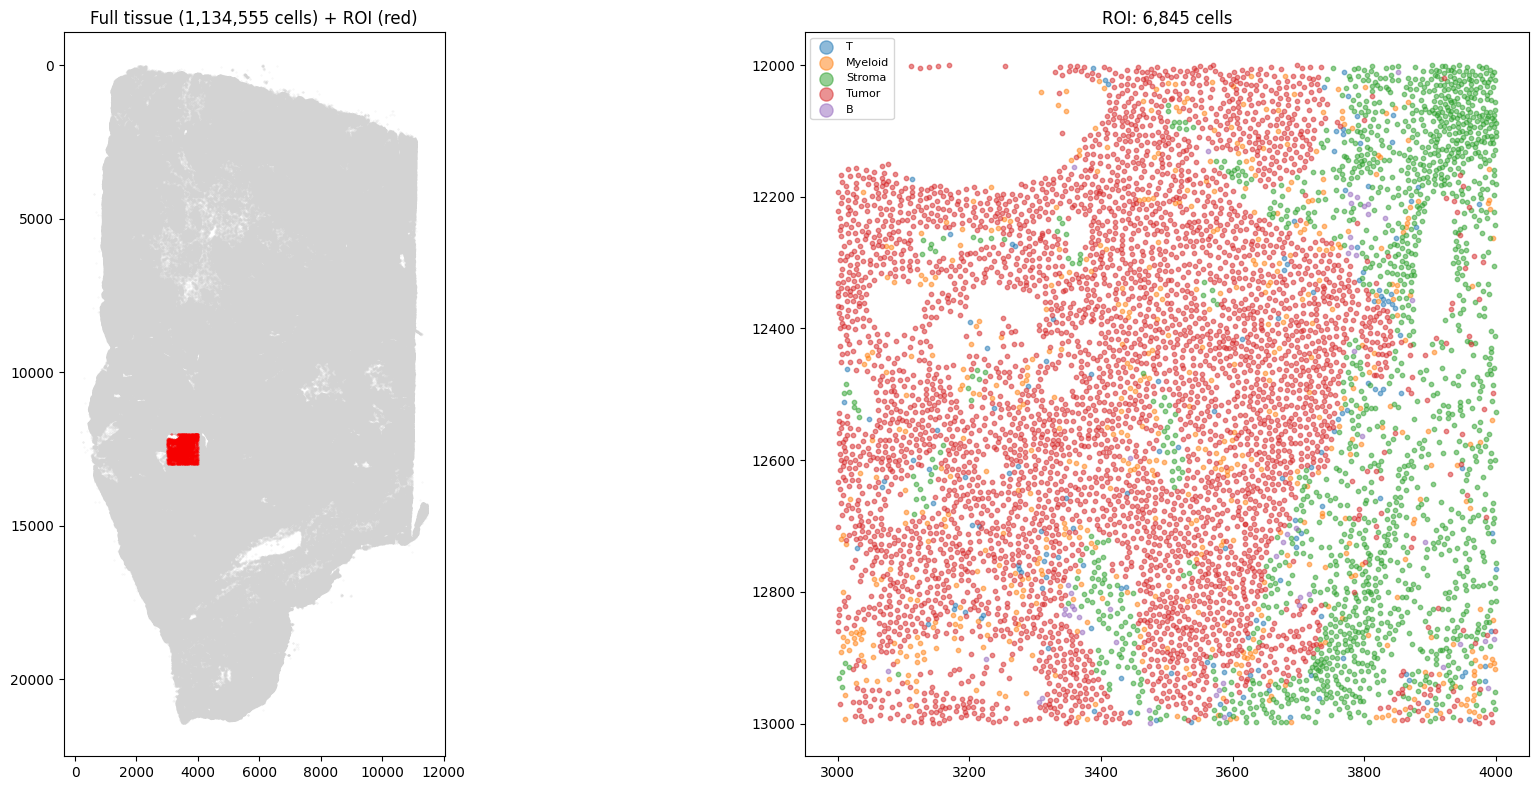

In [15]:
# Visualize your ROI
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Full tissue with ROI box
ax = axes[0]
ax.scatter(sp.spatial.x_global, sp.spatial.y_global, s=0.1, c="lightgray", alpha=0.3)
ax.scatter(sp_roi.spatial.x_global, sp_roi.spatial.y_global, s=0.1, c="red", alpha=0.3)
ax.set_title(f"Full tissue ({len(sp.cell_index):,} cells) + ROI (red)")
ax.set_aspect("equal")
ax.invert_yaxis()

# ROI colored by cell type
ax = axes[1]
for ct in sp_roi.cell_meta["cell_type"].unique():
    mask = sp_roi.cell_meta["cell_type"] == ct
    ax.scatter(
        sp_roi.spatial.x_global[mask.values],
        sp_roi.spatial.y_global[mask.values],
        s=10, label=ct, alpha=0.5,
    )
ax.set_title(f"ROI: {len(sp_roi.cell_index):,} cells")
ax.set_aspect("equal")
ax.invert_yaxis()
ax.legend(markerscale=3, fontsize=8)

plt.tight_layout()
plt.show()

---
## 2. Run CCC on ROI

All downstream analysis uses `sp_roi` instead of the full `sp`.

In [9]:
# Run with defaults on ROI
config_filtered = CCCConfig(
    group_col="cell_type",
    layer="log_normalized",
    buffer_distance=5
)
result = run_ccc(sp_roi, config_filtered)

# Top significant interactions
sig = result.scores[result.scores["fdr"] < 0.05].sort_values("mean_score", ascending=False)
print(f"{len(sig)} significant interactions (FDR < 0.05)")
sig.head(20)

[run_ccc] Loading LR database (source='builtin')
[CCC database] Loaded 39 LR pairs from builtin
  ecm         :    6  (ligand complexes: 0, receptor complexes: 0)
  juxtacrine  :   13  (ligand complexes: 0, receptor complexes: 0)
  secreted    :   20  (ligand complexes: 2, receptor complexes: 4)
[run_ccc] Filtering to expressed pairs (min_pct=0.05)
[CCC filter] 5 / 39 LR pairs pass (min_pct=5%)
  Removed: 12 not in gene panel, 22 below min_pct
[run_ccc] 5 LR pairs will be scored
[run_ccc] Building juxtacrine contact graph (buffer_distance=5)

[Polygon Graph] Building buffer graph (buffer=5)...
Converting to GeoDataFrame (global coordinates)...
  ✓ Created GeoDataFrame: 6845 cells
  → Computing polygon distances for 22373 pairs...
  ✓ Buffer graph: 6845 cells, 22373 edges
    Mean degree: 6.5
    Distance range: 0.0 – 5.0

[Boundaries] Computing contact fractions...
Converting to GeoDataFrame (global coordinates)...
  ✓ Created GeoDataFrame: 6845 cells
Converting to GeoDataFrame (global

,lr_name,sender_type,receiver_type,mean_score,sum_score,n_edges,z_score,pvalue,fdr
56,MMP9-CD44,Myeloid,Myeloid,0.689591,26414.093452,38304,404.246516,0.000000e+00,0.000000e+00
58,MMP9-CD44,Myeloid,T,0.671363,6453.138099,9612,189.785130,0.000000e+00,0.000000e+00
55,MMP9-CD44,Myeloid,B,0.513087,1756.808670,3424,84.483216,0.000000e+00,0.000000e+00
13,CXCL12-CXCR4,Stroma,T,0.285815,8587.582551,30046,201.599975,0.000000e+00,0.000000e+00
10,CXCL12-CXCR4,Stroma,B,0.284881,3495.778165,12271,142.357027,0.000000e+00,0.000000e+00
0,CXCL12-CXCR4,B,B,0.275421,136.608659,496,31.467275,1.218184e-217,5.639740e-217
59,MMP9-CD44,Myeloid,Tumor,0.269288,83721.205117,310898,382.147888,0.000000e+00,0.000000e+00
50,MMP9-CD44,B,B,0.250008,124.003927,496,18.664884,4.779108e-78,1.422354e-77
51,MMP9-CD44,B,Myeloid,0.243085,832.323061,3424,32.140021,6.088058e-227,2.926951e-226
11,CXCL12-CXCR4,Stroma,Myeloid,0.240146,18731.186290,77999,201.578921,0.000000e+00,0.000000e+00


In [12]:
sig

,lr_name,sender_type,receiver_type,mean_score,sum_score,n_edges,z_score,pvalue,fdr
56,MMP9-CD44,Myeloid,Myeloid,0.689591,26414.093452,38304,404.246516,0.000000e+00,0.000000e+00
58,MMP9-CD44,Myeloid,T,0.671363,6453.138099,9612,189.785130,0.000000e+00,0.000000e+00
55,MMP9-CD44,Myeloid,B,0.513087,1756.808670,3424,84.483216,0.000000e+00,0.000000e+00
13,CXCL12-CXCR4,Stroma,T,0.285815,8587.582551,30046,201.599975,0.000000e+00,0.000000e+00
10,CXCL12-CXCR4,Stroma,B,0.284881,3495.778165,12271,142.357027,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...,...,...,...
105,WNT5A-FZD1,Myeloid,B,0.019621,67.183655,3424,6.107533,5.059131e-10,1.090330e-09
101,WNT5A-FZD1,B,Myeloid,0.019416,66.479482,3424,5.990089,1.048628e-09,2.221670e-09
118,WNT5A-FZD1,T,T,0.018386,55.708911,3030,6.195755,2.900321e-10,6.360353e-10
107,WNT5A-FZD1,Myeloid,Stroma,0.014031,1094.377378,77999,4.730723,1.118611e-06,2.292235e-06


In [ ]:
# Run with defaults on ROI
config_filtered = CCCConfig(
    group_col="cell_type",
    layer="log_normalized",
    sender_types=["Stroma"],
    receiver_types=["Tumor"],
    buffer_distance=5
)
result = run_ccc(sp_roi, config_filtered)

# Top significant interactions
sig = result.scores[result.scores["fdr"] < 0.05].sort_values("mean_score", ascending=False)
print(f"{len(sig)} significant interactions (FDR < 0.05)")
sig.head(20)

---
## 3. Custom Configuration

### 3a. Using CellChatDB

Load a larger LR database from CellChatDB CSV.

In [ ]:
# Use CellChatDB — download from https://github.com/sqjin/CellChat
config = CCCConfig(
    db_source="cellchatdb",
    db_csv_path="path/to/CellChatDB_human.csv",  # adjust path
    group_col="cell_type",
    layer="log_normalized",
    min_pct=0.05,
)

result = run_ccc(sp_roi, config)
print(f"{len(result.lr_pairs)} LR pairs tested")
print(f"{len(result.scores)} type-pair interactions scored")

### 3b. Configuring spatial parameters

Default radius is 200 um for secreted/ECM signaling (matches COMMOT's paracrine diffusion range).

In [ ]:
config = CCCConfig(
    group_col="cell_type",
    layer="log_normalized",
    secreted_radius=200.0,
    ecm_radius=200.0,
    buffer_distance=None,         # None = direct polygon contact for juxtacrine
    sigma_secreted=None,          # auto-estimated from median edge distance
    sigma_ecm=None,
    lr_types=["secreted", "ecm"],  # or ["juxtacrine"] or None for all
)

result = run_ccc(sp_roi, config)

### 3c. Significance testing

Two methods:
- **Analytical** (default) — z-score from null distribution moments. Fast.
- **Permutation** — subsampled cells, shuffled labels. More robust for rare cell types.

In [ ]:
# Permutation test (more robust, slower)
config_perm = CCCConfig(
    group_col="cell_type",
    layer="log_normalized",
    test_method="permutation",
    n_subsample=5000,
    n_permutations=1000,
    seed=42,
)

result_perm = run_ccc(sp_roi, config_perm)

### 3d. Filter to specific cell types

In [ ]:
# Only score Tumor -> immune interactions
config_filtered = CCCConfig(
    group_col="cell_type",
    layer="log_normalized",
    sender_types=["Tumor"],
    receiver_types=["T", "Myeloid", "B"],
)

result_filtered = run_ccc(sp_roi, config_filtered)
print(result_filtered.scores.sort_values("mean_score", ascending=False).head(10))

---
## 4. Visualizing Results

### 4a. Score heatmap — sender x receiver

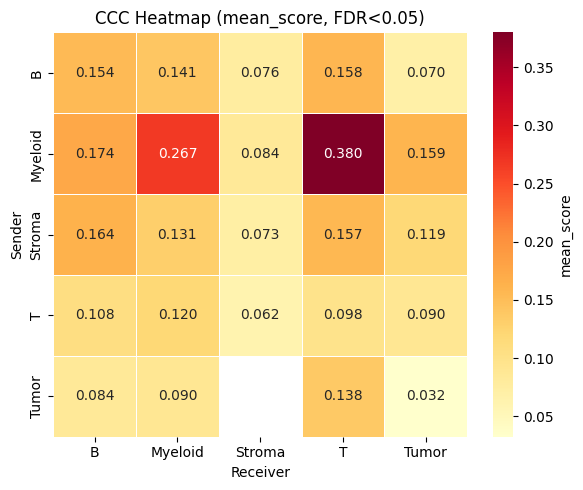

In [10]:
# Heatmap aggregated across all significant LR pairs
sj.visualization.plot_ccc_heatmap(result)

# Heatmap for a specific LR pair
# sj.visualization.plot_ccc_heatmap(result, lr_name="TGFB1_TGFBR1_TGFBR2")

### 4b. Dot plot — top interactions ranked by score

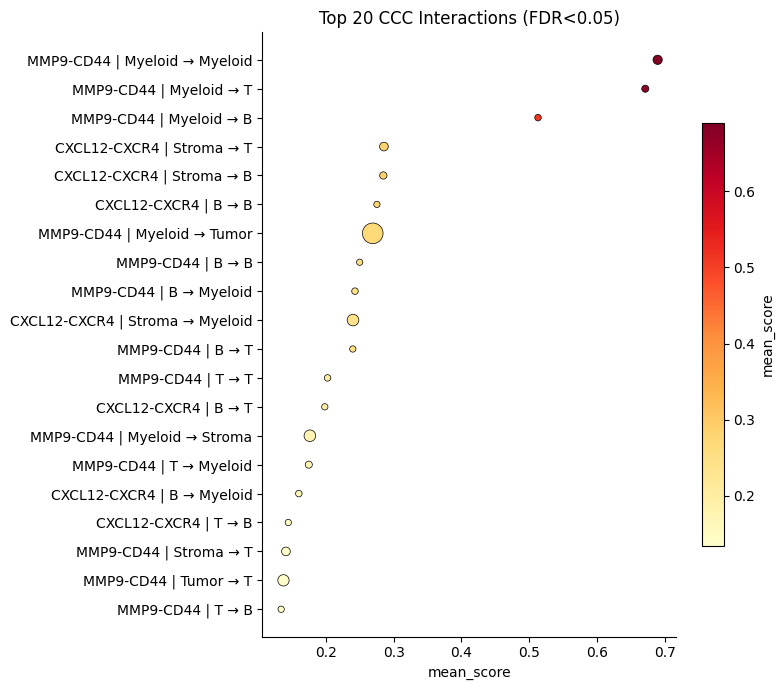

In [11]:
# Top 20 significant interactions (dot size = n_edges, color = score)
sj.visualization.plot_ccc_dotplot(result, top_n=20)

### 4c. Communication network — cell type level

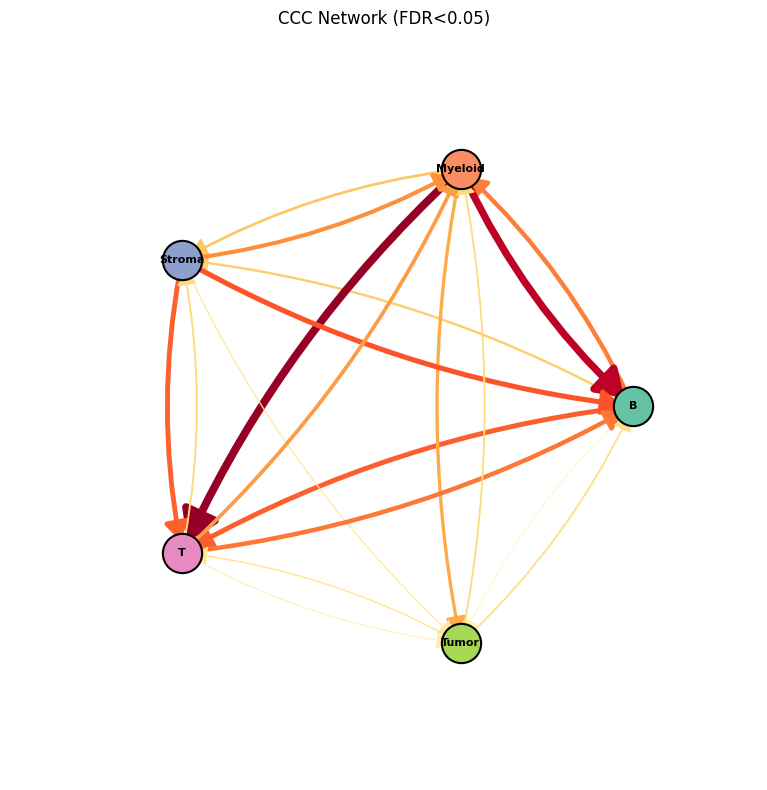

In [12]:
# Directed network: nodes = cell types, edges = total communication score
sj.visualization.plot_ccc_network(result)

### 4d. Spatial map — per-cell sender/receiver scores

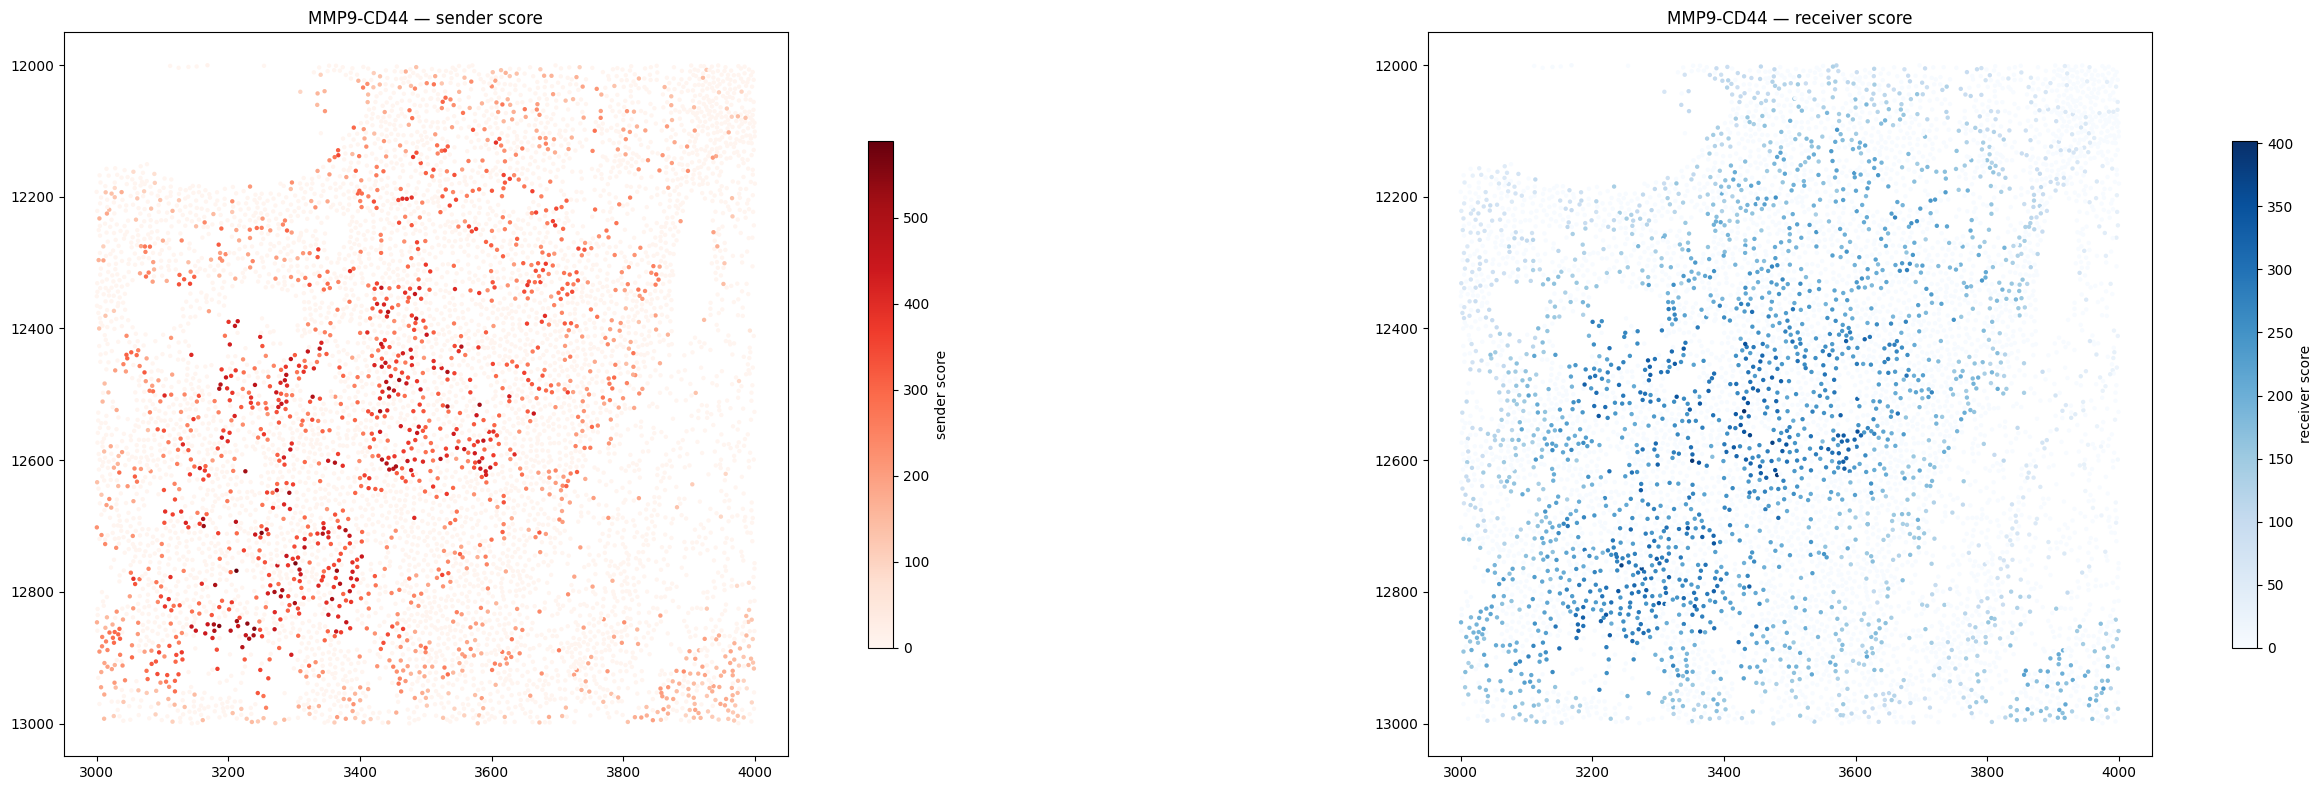

In [18]:
top_lr = result.scores.sort_values("mean_score", ascending=False).iloc[0]["lr_name"]                                                                                                                             
                                                                                                                                                                                                               
fig, axes = plt.subplots(1, 2, figsize=(30, 8))                                                                                                                                                                  
                                                                                                                                                                                                               
# 1. Sender scores
sj.visualization.plot_ccc_spatial(sp_roi, result, lr_name=top_lr, role="sender",
                                cmap="Reds", ax=axes[0], show=False, point_size=10)                                                                                                                            

# 2. Receiver scores                                                                                                                                                                                             
sj.visualization.plot_ccc_spatial(sp_roi, result, lr_name=top_lr, role="receiver",
                                cmap="Blues", ax=axes[1], show=False, point_size=10)                                                                                                                                                                                                                                                                           
              
plt.tight_layout()                                                                                                                                                                                               
plt.show() 

  Saved: xenium_plots/xenium_cell_type_dot_categorical.png


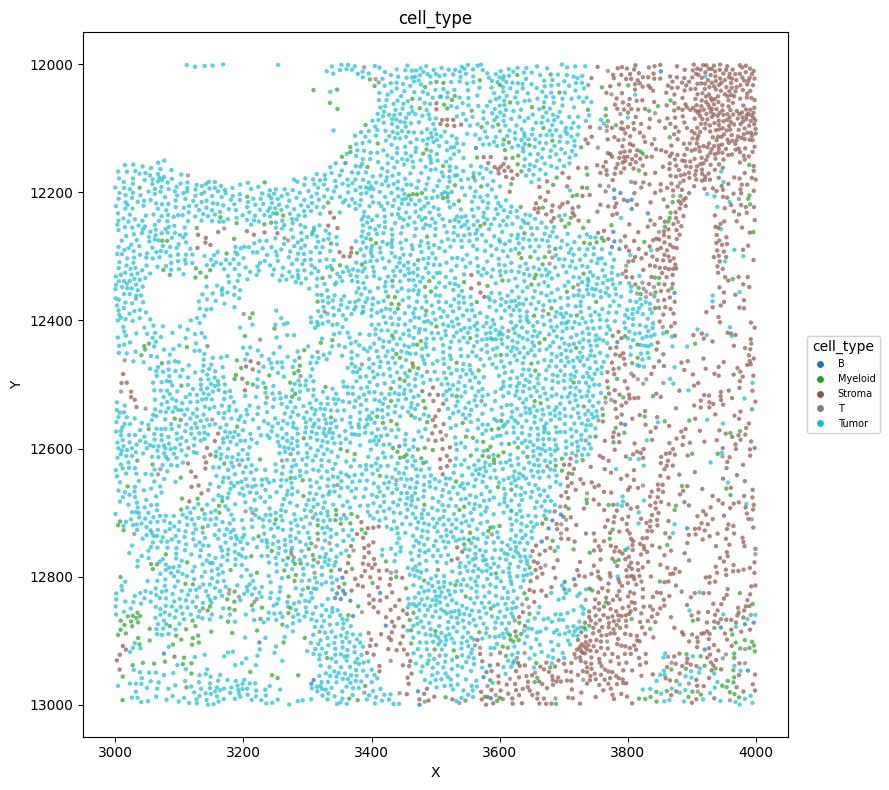

In [22]:
# 3. Cell type map using your built-in plot                                                                                                                                                                      
sj.visualization.xenium_plot_spatial(sp_roi, 
                                     values='cell_type', 
                                     save_dir='xenium_plots',
                                     mode='dot', 
                                     show=True, dot_size=10) 

Converting to GeoDataFrame (global coordinates)...
  ✓ Created GeoDataFrame: 6845 cells
  Saved: xenium_plots/xenium_cell_type_polygon_categorical.png


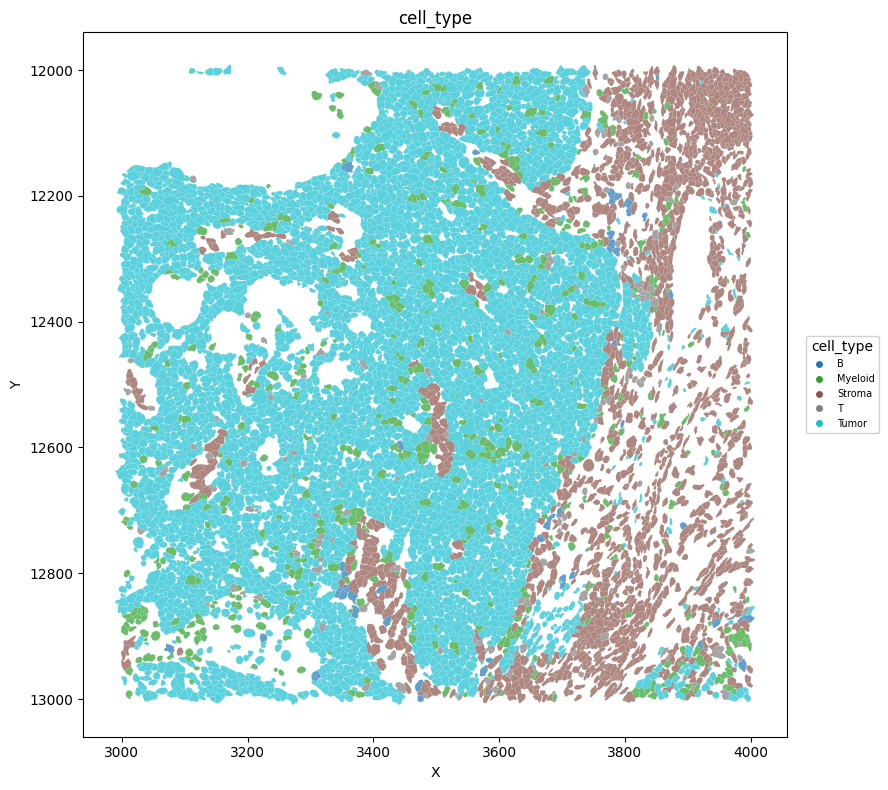

In [7]:
sj.visualization.xenium_plot_spatial(sp_roi, 
                                     values='cell_type', 
                                     save_dir='xenium_plots',
                                     mode='polygon', 
                                     show=True) 

---
## 5. Interface-Aware CCC

**What makes spatioloji_s unique:** stratify communication by spatial zone relative to a tissue boundary.

### 5a. Run CCC with interface

In [7]:
import spatioloji_s.spatial.point as spoint

# Identify interface on the ROI
iface = spoint.identify_interface(
    sp_roi, group_col="cell_type",
    region_a="Tumor", region_b="Stroma",
    grid_resolution=50,
)

# Run CCC with interface awareness
config_iface = CCCConfig(
    group_col="cell_type",
    layer="log_normalized",
    interface_result=iface,
    n_distance_bins=20,
    buffer_distance=5
)

result_iface = run_ccc(sp_roi, config_iface)


[Interface] Identifying interface: ['Tumor'] vs ['Stroma']
  Auto distance_threshold=30.6 (1.5x tile size)
  Stored 'interface_label' in cell_meta
  1966 interface cells (1071 region_a, 895 region_b)
  31 segment(s)
[run_ccc] Loading LR database (source='builtin')
[CCC database] Loaded 39 LR pairs from builtin
  ecm         :    6  (ligand complexes: 0, receptor complexes: 0)
  juxtacrine  :   13  (ligand complexes: 0, receptor complexes: 0)
  secreted    :   20  (ligand complexes: 2, receptor complexes: 4)
[run_ccc] Filtering to expressed pairs (min_pct=0.05)
[CCC filter] 5 / 39 LR pairs pass (min_pct=5%)
  Removed: 12 not in gene panel, 22 below min_pct
[run_ccc] 5 LR pairs will be scored
[run_ccc] Building juxtacrine contact graph (buffer_distance=5)

[Polygon Graph] Building buffer graph (buffer=5)...
Converting to GeoDataFrame (global coordinates)...
  ✓ Created GeoDataFrame: 6845 cells
  → Computing polygon distances for 22373 pairs...
  ✓ Buffer graph: 6845 cells, 22373 edges
 

In [11]:
with open('xenium_data/result_iface.pkl', 'wb') as f:
    pickle.dump(result_iface, f)

In [4]:
with open('xenium_data/result_iface.pkl', 'rb') as f:
    result_iface = pickle.load(f)

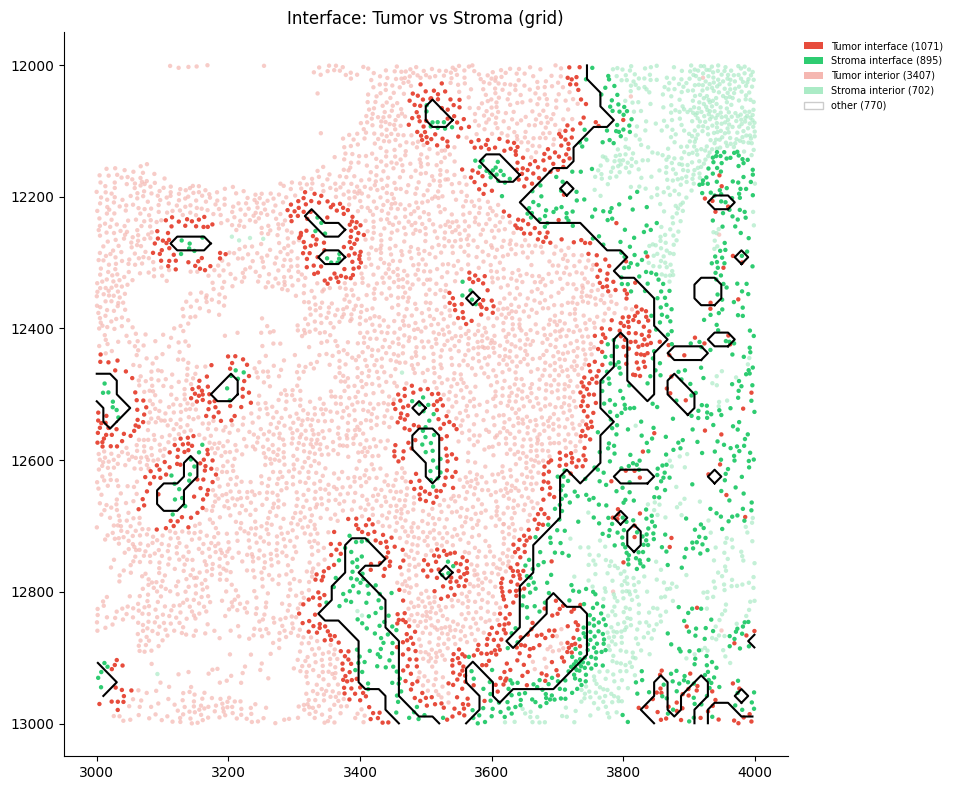

In [6]:
sj.visualization.plot_interface_point_map(
    sp_roi, iface,
    color_a='#e74c3c',     # red for region A
    color_b='#2ecc71',     # green for region B
    point_size=10,
    contour_width=1.5,
    dpi=200, show_seg_labels=False
)

In [7]:
iface

InterfaceResult(cell_labels=cell_id
dcjebgcm-1                 other
dcjeeade-1                 other
dcjmclem-1                 other
dcjmdfai-1    region_b_interface
dcjmdidk-1                 other
                     ...        
oikhlpio-1                 other
oikhmbpg-1            interior_a
oiklabnb-1    region_a_interface
oiklcbjk-1            interior_a
oikldcmf-1    region_a_interface
Length: 6845, dtype: object, contour=<MULTILINESTRING ((3928.424 12999.57, 3928.424 12978.959, 3938.625 12968.548...>, segments=    segment_id                                           geometry  \
0            0  LINESTRING (3928.424 12999.57, 3928.424 12978....   
1            1  LINESTRING (3998.998 12884.4, 3989.633 12874.8...   
2            2  LINESTRING (3744.798 12000.483, 3744.798 12021...   
3            3  LINESTRING (3846.641 12999.608, 3836.611 12989...   
4            4  LINESTRING (3540.77 12083.54, 3530.568 12073.1...   
5            5  LINESTRING (3642.784 12166.835, 3632.583 12

## top ranks based on fold_change
fold_change = zone_mean_score / overall_mean_score                                                                                             
Specifically:                                                                                                                                  
  1. overall_mean (line 116): mean of score across all edges for each (lr_name, sender_type, receiver_type) group, regardless of zone            
  2. zone_mean_score (line 129): mean of score for edges in that specific zone (interface, interior_a, or interior_b)
  3. fold_change (line 155): zone_mean_score / overall_mean_score (NaN if overall is 0)

  So a fold_change of 2.0 at the interface means that interaction is 2x stronger at the interface than the global average. The plotting function 
  then ranks by interface fold_change descending — interactions most enriched at the interface appear first.

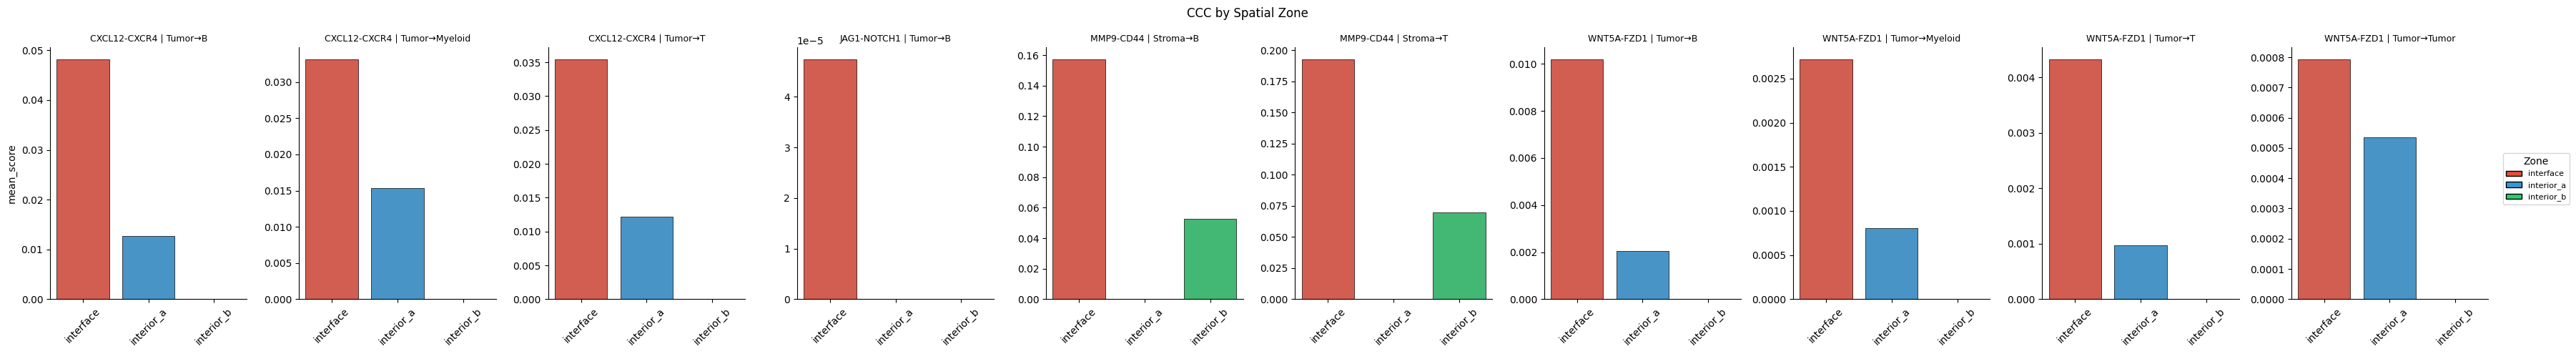

In [5]:
# Zone comparison: grouped bar chart (interface vs interior_a vs interior_b)
# any edge where at least one end is a Tumor or Stroma cell is included. Only edges where both sender and receiver are non-Tumor/non-Stroma are dropped
sj.visualization.plot_ccc_zones(result_iface, top_n=10)

### 5b. Communication gradient

Horizontal bar chart of gradient slopes. Solid = significant (p < 0.05), hatched = non-significant.

In [6]:
result_iface

CCCResult(scores=          lr_name sender_type receiver_type  mean_score    sum_score  n_edges  \
0    CXCL12-CXCR4           B             B    0.275421   136.608659      496   
1    CXCL12-CXCR4           B       Myeloid    0.160220   548.592690     3424   
2    CXCL12-CXCR4           B        Stroma    0.112864  1384.950915    12271   
3    CXCL12-CXCR4           B             T    0.198548   237.463522     1196   
4    CXCL12-CXCR4           B         Tumor    0.070110  1596.828685    22776   
..            ...         ...           ...         ...          ...      ...   
120    WNT5A-FZD1       Tumor             B    0.004693   106.881712    22776   
121    WNT5A-FZD1       Tumor       Myeloid    0.001233   383.446713   310898   
122    WNT5A-FZD1       Tumor        Stroma    0.004892  1831.496191   374422   
123    WNT5A-FZD1       Tumor             T    0.001874   135.230070    72179   
124    WNT5A-FZD1       Tumor         Tumor    0.000575  1672.901732  2911700   

        z_

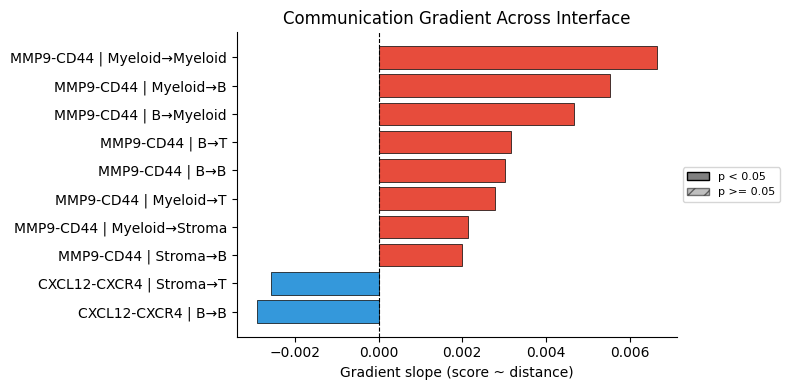

In [7]:
# Gradient slopes — which interactions change most across the interface?
sj.visualization.plot_ccc_gradient(result_iface, top_n=10)

---
## 6. Morphology Stratification

Compare communication patterns across cell shape groups.

[run_ccc] Loading LR database (source='builtin')
[CCC database] Loaded 39 LR pairs from builtin
  ecm         :    6  (ligand complexes: 0, receptor complexes: 0)
  juxtacrine  :   13  (ligand complexes: 0, receptor complexes: 0)
  secreted    :   20  (ligand complexes: 2, receptor complexes: 4)
[run_ccc] Filtering to expressed pairs (min_pct=0.05)
[CCC filter] 5 / 39 LR pairs pass (min_pct=5%)
  Removed: 12 not in gene panel, 22 below min_pct
[run_ccc] 5 LR pairs will be scored
[run_ccc] Building juxtacrine contact graph (buffer_distance=5)

[Polygon Graph] Building buffer graph (buffer=5)...
Converting to GeoDataFrame (global coordinates)...
  ✓ Created GeoDataFrame: 6845 cells
  → Computing polygon distances for 22373 pairs...
  ✓ Buffer graph: 6845 cells, 22373 edges
    Mean degree: 6.5
    Distance range: 0.0 – 5.0

[Boundaries] Computing contact fractions...
Converting to GeoDataFrame (global coordinates)...
  ✓ Created GeoDataFrame: 6845 cells
Converting to GeoDataFrame (global

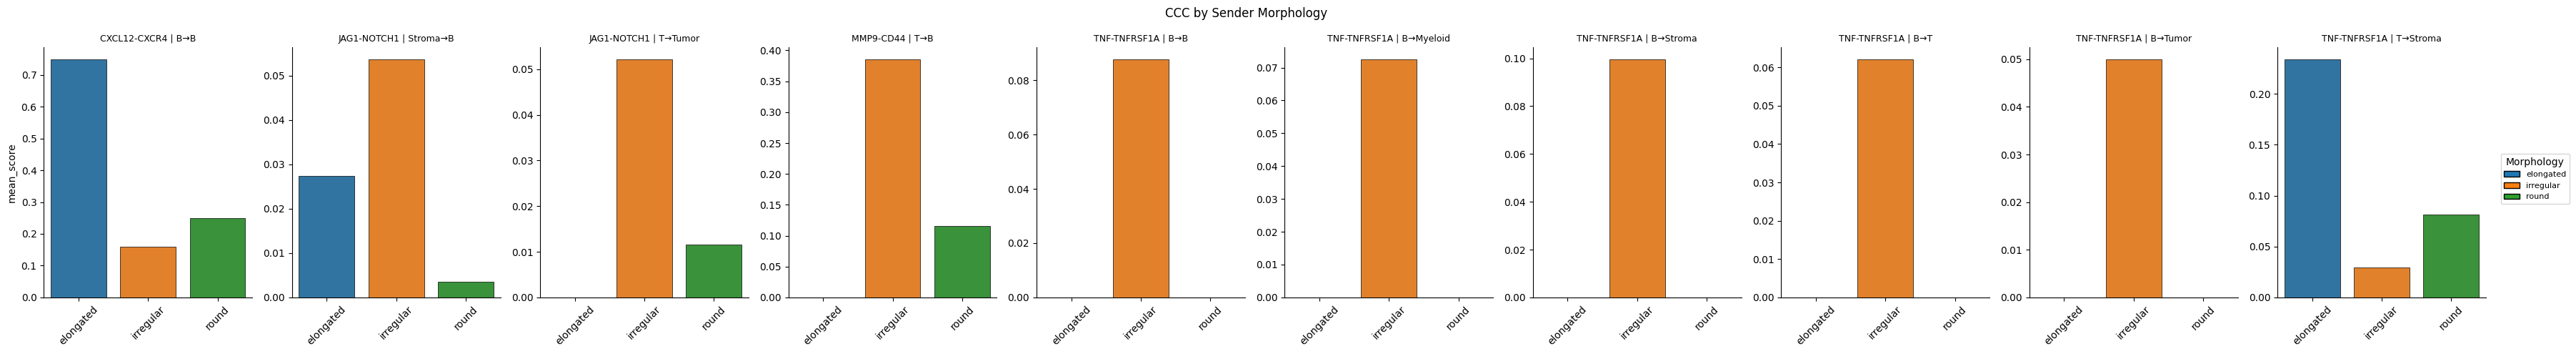

In [8]:
# Run CCC with morphology stratification
config_morph = CCCConfig(
    group_col="cell_type",
    layer="log_normalized",
    morphology_col="morph_class",
    buffer_distance=5
)

result_morph = run_ccc(sp_roi, config_morph)

# Grouped bar chart by morphology
sj.visualization.plot_ccc_morphology(result_morph, top_n=10)

---
## 7. Summary Panel — All Plots Together

In [ ]:
# Run full pipeline
config_full = CCCConfig(
    group_col="cell_type",
    layer="log_normalized",
    interface_result=iface,
    n_distance_bins=20,
    morphology_col="morph_class",
)
result_full = run_ccc(sp_roi, config_full)

# Multi-panel summary
fig, axes = plt.subplots(2, 3, figsize=(24, 14))

# Row 1: core results
sj.visualization.plot_ccc_heatmap(result_full, ax=axes[0, 0], show=False, title="Score Heatmap")
sj.visualization.plot_ccc_network(result_full, show=False)  # network needs its own fig
top_lr = result_full.scores.sort_values("mean_score", ascending=False).iloc[0]["lr_name"]
sj.visualization.plot_ccc_spatial(sp_roi, result_full, lr_name=top_lr, role="sender", ax=axes[0, 1], show=False)
sj.visualization.plot_ccc_spatial(sp_roi, result_full, lr_name=top_lr, role="receiver", cmap="Blues", ax=axes[0, 2], show=False)

# Row 2: interface + morphology
sj.visualization.plot_ccc_zones(result_full, top_n=5, ax=axes[1, 0], show=False)
sj.visualization.plot_ccc_gradient(result_full, top_n=5, ax=axes[1, 1], show=False)
sj.visualization.plot_ccc_morphology(result_full, top_n=5, ax=axes[1, 2], show=False)

plt.suptitle("CCC Analysis Summary", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

---
## 8. Low-Level API

Use scoring functions directly for custom analyses.

In [ ]:
from spatioloji_s.ccc.database import LRPair, load_lr_database, filter_to_expressed
from spatioloji_s.ccc.scoring import score_edges, aggregate_scores, test_significance
from spatioloji_s.ccc.zones import compare_zones, communication_gradient, compare_morphology
from spatioloji_s.spatial.point.graph import build_radius_graph

# 1. Load and filter LR pairs
pairs = load_lr_database("builtin")
pairs = filter_to_expressed(pairs, sp_roi, min_pct=0.05)
print(f"{len(pairs)} expressed LR pairs")

# 2. Build graph on ROI
graph = build_radius_graph(sp_roi, radius=200, coord_type="global")

# 3. Score edges
edges = score_edges(sp_roi, pairs, graph_diffusible=graph, group_col="cell_type", layer="log_normalized")
print(f"{len(edges)} edges scored")

# 4. Aggregate
summary, cell_scores = aggregate_scores(edges, sp_roi, group_col="cell_type")

# 5. Test significance
summary = test_significance(summary, edges, sp_roi, group_col="cell_type", method="analytical")

# 6. Zone comparison (requires interface result)
zone_df = compare_zones(edges, sp_roi, iface, group_col="cell_type")

# 7. Communication gradient
grad_df = communication_gradient(edges, sp_roi, iface, group_col="cell_type", n_bins=20)

---
## Quick Reference

```python
from spatioloji_s.ccc import CCCConfig, run_ccc

# -- Step 1: Always subset to ROI first --
x, y = sp.spatial.x_global, sp.spatial.y_global
roi_cells = sp.cell_index[(x > x_min) & (x < x_max) & (y > y_min) & (y < y_max)]
sp_roi = sp.subset_by_cells(roi_cells)

# -- Step 2: Run CCC on ROI --
result = run_ccc(sp_roi)
result = run_ccc(sp_roi, CCCConfig(db_source="cellchatdb", db_csv_path="CellChatDB.csv"))
result = run_ccc(sp_roi, CCCConfig(test_method="permutation", n_subsample=5000))
result = run_ccc(sp_roi, CCCConfig(sender_types=["Tumor"], receiver_types=["T"]))

# -- Interface-aware --
iface = spoint.identify_interface(sp_roi, group_col="cell_type",
    region_a="Tumor", region_b="Stroma")
result = run_ccc(sp_roi, CCCConfig(interface_result=iface))

# -- Morphology --
result = run_ccc(sp_roi, CCCConfig(morphology_col="morph_class"))

# -- Step 3: Visualize --
sj.visualization.plot_ccc_heatmap(result)                           # sender x receiver heatmap
sj.visualization.plot_ccc_dotplot(result, top_n=20)                 # top interactions dot plot
sj.visualization.plot_ccc_network(result)                           # cell type network
sj.visualization.plot_ccc_spatial(sp_roi, result, lr_name, "sender")# spatial sender scores
sj.visualization.plot_ccc_spatial(sp_roi, result, lr_name, "receiver", cmap="Blues")
sj.visualization.plot_ccc_zones(result, top_n=10)                   # zone bar chart
sj.visualization.plot_ccc_gradient(result, top_n=10)                # gradient slopes
sj.visualization.plot_ccc_morphology(result, top_n=10)              # morphology bar chart
```